In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

In [47]:
# =========================
# PARAMÈTRES
# =========================
csv_file = ".\\inputs\\imu_y_2_.csv"   # ton fichier
column_name = "y0000"       # colonne à lire
fs = 100.0              # fréquence d'échantillonnage (Hz)
cutoff = 0.05            # fréquence de coupure (Hz)


In [48]:
# =========================
# LECTURE CSV
# =========================
df = pd.read_csv(csv_file)
signal = df[column_name].values

# Si pas de temps, on le génère
t = np.arange(len(signal)) / fs

In [49]:
# =========================
# FFT
# =========================
fft_vals = np.fft.fft(signal)
freqs = np.fft.fftfreq(len(signal), d=1/fs)

# On garde uniquement la partie positive
mask = freqs >= 0
freqs = freqs[mask]
fft_vals = np.abs(fft_vals[mask])

In [50]:
# =========================
# FILTRES PASSE-BAS
# =========================
def lowpass(signal, cutoff, fs, order):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    return filtfilt(b, a, signal)

signal_lp1 = lowpass(signal, cutoff, fs, order=1)
signal_lp2 = lowpass(signal, cutoff, fs, order=2)

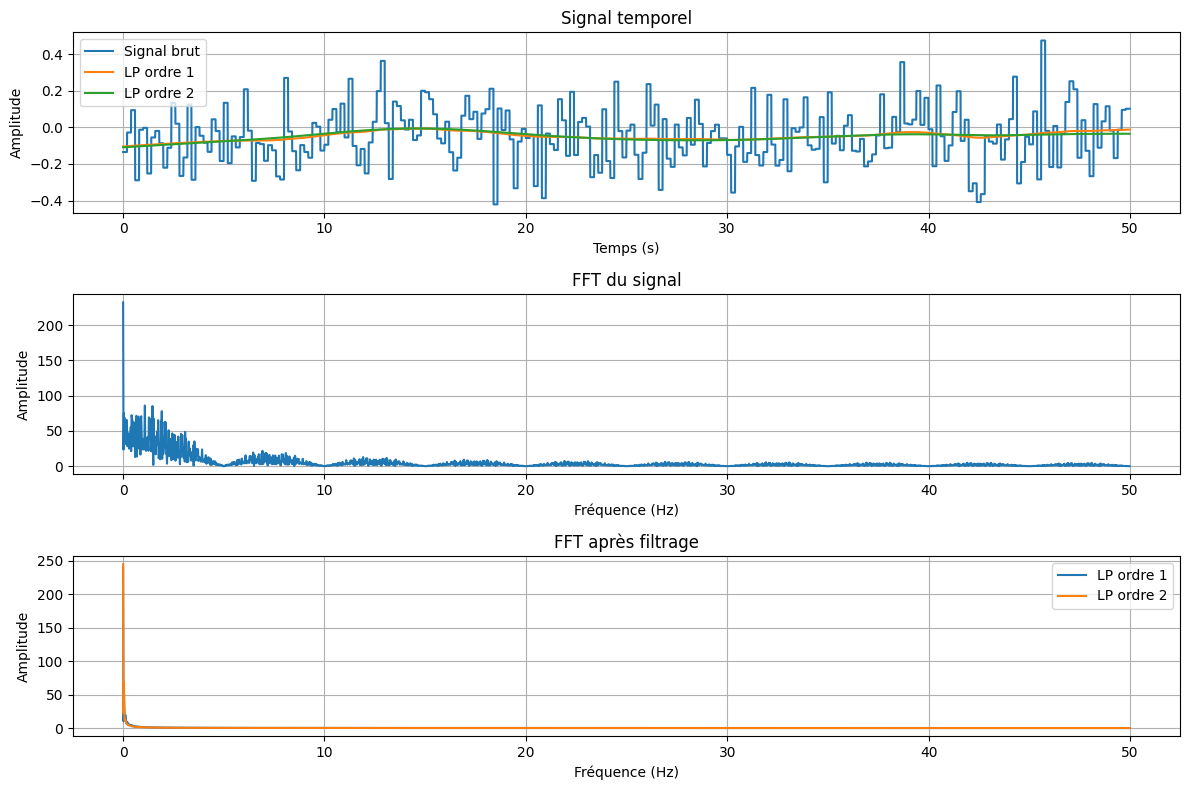

In [51]:
# =========================
# PLOTS
# =========================
plt.figure(figsize=(12, 8))

# Signal brut
plt.subplot(3,1,1)
plt.plot(t, signal, label="Signal brut")
plt.plot(t, signal_lp1, label="LP ordre 1")
plt.plot(t, signal_lp2, label="LP ordre 2")
plt.title("Signal temporel")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

# FFT
plt.subplot(3,1,2)
plt.plot(freqs, fft_vals)
plt.title("FFT du signal")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Amplitude")
plt.grid()

# FFT après filtrage
fft_lp1 = np.abs(np.fft.fft(signal_lp1))[mask]
fft_lp2 = np.abs(np.fft.fft(signal_lp2))[mask]

plt.subplot(3,1,3)
plt.plot(freqs, fft_lp1, label="LP ordre 1")
plt.plot(freqs, fft_lp2, label="LP ordre 2")
plt.title("FFT après filtrage")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()